In [19]:
import pyvista as pv
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd

import os
    
import imageio

%matplotlib inline

from scipy.stats import binned_statistic_2d


In [3]:
Case_folder_a = ['~/work/gpusph/spheric2022_gpusph/tests/MYBreakRoughTank_v6_2026-01-20T06h47/data/', ]


fig_folder_a = ['figures_MyBreakRoughTank_v6_3a-iv/',
               ]
# cname = ['0.0d','0.1d','0.2d','0.3d','0.4d','0.5d','0.6d','0.7d','0.8d','0.9d','1.0d']
# try:
#     os.mkdir(fig_folder)
#     print(f"Folder '{fig_folder}' created.")
# except FileExistsError:
#     print(f"Folder '{fig_folder}' already exists.")

~/work/gpusph/spheric2022_gpusph/tests/MYBreakRoughTank_v6_2026-01-20T06h47/data/ figures_MyBreakRoughTank_v6_3a-iv/
0


(-0.2, 3.3)

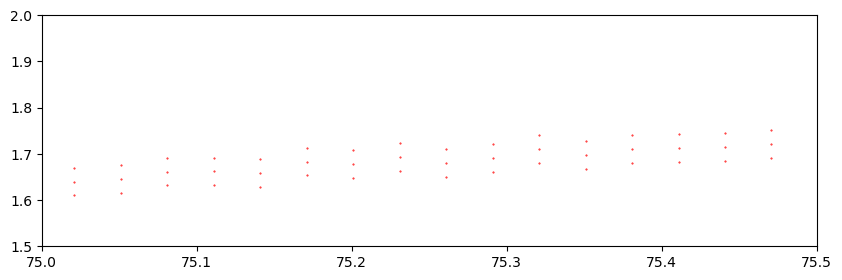

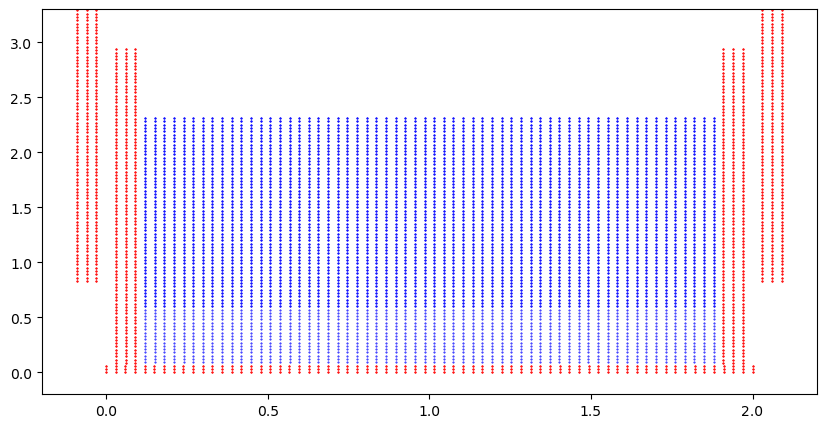

In [17]:
itmin = 0
itmax = 0
idt = 1
id0 = 431010

for icase in [0]:
    Case_folder = Case_folder_a[icase]
    fig_folder = fig_folder_a[icase]
    print(Case_folder,fig_folder)
    # try:
    #     os.mkdir(fig_folder)
    #     print(f"Folder '{fig_folder}' created.")
    # except FileExistsError:
    #     print(f"Folder '{fig_folder}' already exists.")
        
    for i in range(itmin,itmax+idt,idt):
        print(i)
        data = pv.read(f'{Case_folder}PART_{i:05d}.vtp')
        # data = pv.read(f'WaveTank_2025-08-19T00h39/data/PART_{i:05d}.vtp')
        # data = pv.read(f'HinsdaleFlume_2025-08-22T00h42/data/PART_{i:05d}.vtp')
        # part_water = data.points[np.where(data['Part type']==0)]
        # # part_water = data.points[np.where((data['Part type']==0)|(data['Part type']==1))]
        # velo_water = data['Velocity'][np.where(data['Part type']==0)]

x = data.points[:,0]
y = data.points[:,1]
z = data.points[:,2]
pty = data['Part type']

mask = (y >= 0.6) & (y <= 0.63) & (pty==0)
# mask = (y >= -0.2) & (y <= 0) & (pty==0)
mask_wall = (y >= 0.6) & (y <= 0.63) & (pty==1)
mask_wall2 = (y <= 0.3) & (pty==1)
# mask = (y >= 0.0) & (y <= 2)& (pty==1)

xsec = x[mask]
zsec = z[mask]
xsec_wall = x[mask_wall]
zsec_wall = z[mask_wall]
xsec_wall2 = x[mask_wall2]
zsec_wall2 = z[mask_wall2]


mask2 = (z <= 1.5) &(z >= 1.45) & (pty==1)
xsec2 = x[mask2]
ysec2 = y[mask2]
zsec2 = z[mask2]

mask3 = (x <= 1.5) &(x >= 1.45) & (pty==0)
mask3_wall = (x <= 1.5) &(x >= 1.45) & (pty==1)
xsec3 = x[mask3]
ysec3 = y[mask3]
zsec3 = z[mask3]
xsec3_wall = x[mask3_wall]
ysec3_wall = y[mask3_wall]
zsec3_wall = z[mask3_wall]

# id0 = 6458318
plt.figure(figsize=(10,3))
plt.scatter(xsec,zsec,0.2)
# plt.scatter(xsec_wall2,zsec_wall2,0.2,'k')
plt.scatter(xsec_wall,zsec_wall,0.2,'r')
plt.plot(data.points[:,0][id0], data.points[:,2][id0],'or')
# plt.ylim(-0.2,2.4)
plt.ylim(1.5,2)
plt.xlim(75,75.5)

# plt.figure(figsize=(10,5))
# plt.scatter(xsec2,ysec2,0.2,'r')
# plt.plot(data.points[:,0][id0], data.points[:,2][id0],'or')
# plt.ylim(-0.2,0.3)

plt.figure(figsize=(10,5))
# plt.scatter(ysec3_wall,zsec3_wall,0.3,'r')
plt.scatter(ysec3,zsec3,0.2,'b')
plt.scatter(ysec3_wall,zsec3_wall,0.2,'r')
# plt.plot(data.points[:,0][id0], data.points[:,2][id0],'or')
# plt.xlim(-0.2,0.3)
plt.ylim(-0.2,3.3)

## read DEM file


In [29]:
df = pd.read_csv("../../cobble_surface_with_slope.txt", header=5)   # must contain a column "diameter_m"
df[33,:]

InvalidIndexError: (33, slice(None, None, None))

(35.0, 40.0)

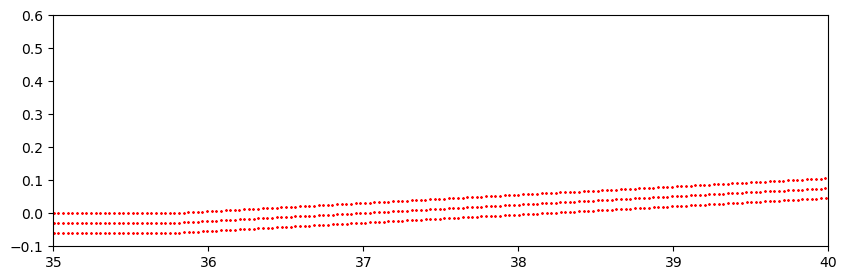

In [38]:
plt.figure(figsize=(10,3))
plt.scatter(xsec,zsec,0.2)
plt.scatter(xsec_wall,zsec_wall,0.2,'r')
# plt.plot(data.points[:,0][id0], data.points[:,2][id0],'or')
plt.ylim(-0.1,0.6)
plt.xlim(35,40)

In [6]:
itmin = 24
itmax = 69
idt = 1

for icase in [0]:
    Case_folder = Case_folder_a[icase]
    fig_folder = fig_folder_a[icase]
    print(Case_folder,fig_folder)
    try:
        os.mkdir(fig_folder)
        print(f"Folder '{fig_folder}' created.")
    except FileExistsError:
        print(f"Folder '{fig_folder}' already exists.")
        
    for i in range(itmin,itmax+idt,idt):
        print(i)
        data = pv.read(f'{Case_folder}PART_{i:05d}.vtp')
        # data = pv.read(f'WaveTank_2025-08-19T00h39/data/PART_{i:05d}.vtp')
        # data = pv.read(f'HinsdaleFlume_2025-08-22T00h42/data/PART_{i:05d}.vtp')
        part_water = data.points[np.where(data['Part type']==0)]
        # part_water = data.points[np.where((data['Part type']==0)|(data['Part type']==1))]
        velo_water = data['Velocity'][np.where(data['Part type']==0)]
        # velo_water = data['Velocity'][np.where((data['Part type']==0)|(data['Part type']==1))]
    
        # Find water particles with y-coordinates between 1.45 and 1.55
        # mask = (part_water[:, 1] >= 0.1) & (part_water[:, 1] <= 0.2)
        mask = (part_water[:, 1] >= 1.0) & (part_water[:, 1] <= 1.35)
        filtered_particles = part_water[mask]
        velo_particles = velo_water[mask]
        # speed_particles = np.sqrt(velo_particles[:,0]**2+velo_particles[:,1]**2+velo_particles[:,2]**2)
    
        plt.figure(figsize=(15, 3))
        plt.scatter(filtered_particles[:, 0], filtered_particles[:, 2], s=1, c=velo_particles[:,0],cmap='coolwarm',vmax=2.5,vmin=-2.5, alpha=1)
        # plt.scatter(filtered_particles[:, 0], filtered_particles[:, 2], s=1, c='grey')
        plt.colorbar()
        plt.xlabel('X position')
        plt.ylabel('Z position')
        # plt.xlim(0,45.5)
        # plt.xlim(0.,83)
        plt.xlim(51,85.5)
        plt.ylim(0., 3)
        plt.title(f'Water particles at time {i*0.25:.2f} s')
        plt.grid(True)
        plt.savefig(f'{fig_folder}/water_particles_horvel_{i:03d}.png')
        plt.close()

    

~/work/gpusph/spheric2022_gpusph/tests/MYBreakRoughTank_v6_2026-01-20T06h47/data/ figures_MyBreakRoughTank_v6_3a-iv/
Folder 'figures_MyBreakRoughTank_v6_3a-iv/' already exists.
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69


5213641

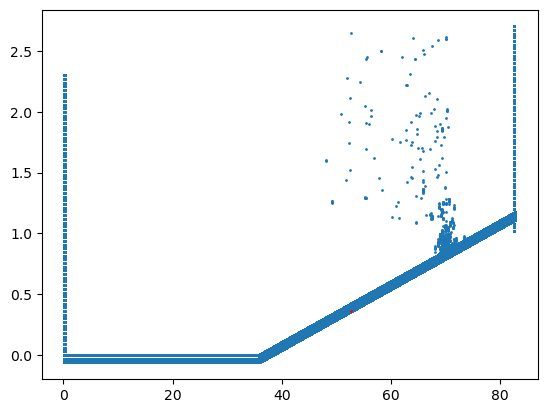

In [46]:
i=35
data = pv.read(f'{Case_folder}PART_{i:05d}.vtp')
mask = (data.points[:, 1] > 0.01) & (data.points[:, 1] < 1.99)
filtered_particles = data.points[mask]
id_particles = data['Part id'][mask]
plt.scatter(filtered_particles[:, 0], filtered_particles[:, 2], s=1)
plt.scatter(filtered_particles[356142, 0], filtered_particles[356142, 2], s=1,c='r')
id_particles[356142]

In [24]:
np.min(data.points[:, 1])

-0.07638546172529459

In [40]:
data['Part type'][np.where(data['Part id']==425529)]

pyvista_ndarray([1], dtype=uint8)

In [7]:
idx = np.where((filtered_particles[:, 2] > 1) &
               (filtered_particles[:, 2] < 1.1) &
               (filtered_particles[:, 0] > 20) &
               (filtered_particles[:, 0] < 20.1))[0]
idx

array([356142, 356144, 356147, 356148, 356149, 356151, 356153, 356154,
       356155, 356158, 356159, 356161, 356166, 356169, 356171, 356176,
       356178, 356179, 356181, 356184, 356187, 356190, 356192, 356194,
       356196, 356197, 356199, 356201, 356206, 356209, 356210, 356214,
       356215, 356218, 356219, 356220, 356222, 356223, 356225, 356228,
       356229, 356230, 356231, 356232, 356234, 356235, 356237, 356239,
       356240, 356241, 356243, 356245, 356246, 356248, 356249, 356250,
       356251, 356252, 356255, 356258, 356261, 356263, 356267, 356269,
       356271, 356272, 356274, 356276, 356277, 356280, 356281, 356282,
       356283, 356285, 356288, 356289, 356290, 356291, 356292, 356293,
       356295, 356296, 356297, 357369, 357374, 357375, 357380, 357384,
       357389, 357391, 357393, 357395, 357396, 357402, 357407, 357408,
       357410, 357413, 357419, 357424, 357426, 357427, 357431, 357432,
       357439, 357440, 357444, 357449, 357453, 357455, 357456, 357461,
      

In [ ]:
plt.plot(data.points[:,0],data.points[:,2])

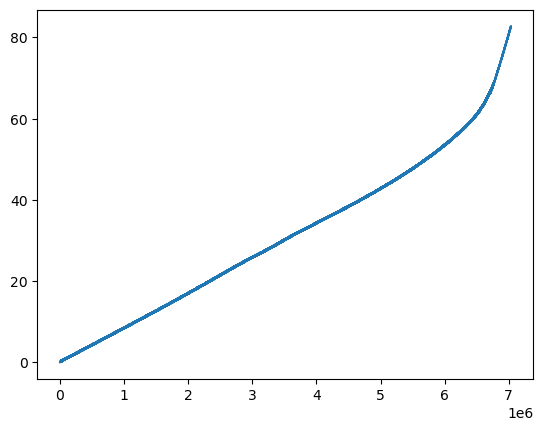

In [21]:
plt.plot(data.points[:,0])

In [12]:
filtered_particles[:, 0].shape

(1005779,)

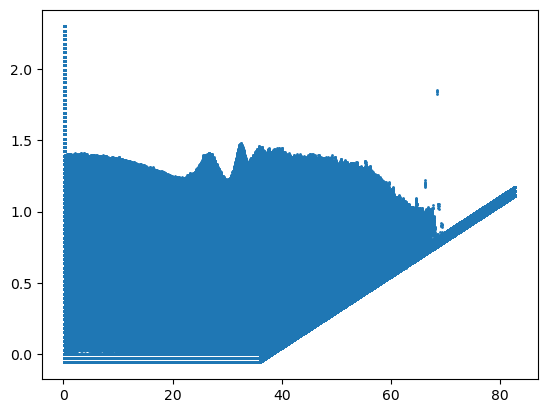

In [13]:
plt.scatter(filtered_particles[:, 0], filtered_particles[:, 2], s=1)

In [88]:
# Create a GIF from the saved PNG images
itmax = 100
idt = 4
# fig_folder = 'figures_MyBreakTank_v2_step5a/'
png_files = [f'{fig_folder}/water_particles_horvel_{i:03d}.png' for i in range(0, itmax+idt, idt)]

# Check if all files exist
existing_files = [f for f in png_files if os.path.exists(f)]
if existing_files:
    # Create the gif
    with imageio.get_writer(f'{fig_folder}/water_particles_animation_zoomin.gif', mode='I', duration=2, loop=0) as writer:
        for filename in existing_files:
            image = imageio.v2.imread(filename)
            writer.append_data(image)

    print(f"Created GIF with {len(existing_files)} frames at '{fig_folder}/water_particles_animation_zoomin.gif'")
else:
    print("No PNG files found to create GIF.")

Created GIF with 18 frames at 'figures_MyBreakRoughTank_v5_3f-i//water_particles_animation_zoomin.gif'


In [5]:
# Create a GIF from the saved PNG images
itmax = 80
idt = 1
# fig_folder = 'figures_MyBreakTank_v2_step5a/'
png_files = [f'{fig_folder}/water_particles_smaller_{i:03d}.png' for i in range(0, itmax+idt, idt)]

# Check if all files exist
existing_files = [f for f in png_files if os.path.exists(f)]
if existing_files:
    # Create the gif
    with imageio.get_writer(f'{fig_folder}/water_particles_animation_zoomout.gif', mode='I', duration=0.8, loop=0) as writer:
        for filename in existing_files:
            image = imageio.v2.imread(filename)
            writer.append_data(image)

    print(f"Created GIF with {len(existing_files)} frames at '{fig_folder}/water_particles_animation_zoomout.gif'")
else:
    print("No PNG files found to create GIF.")

Created GIF with 81 frames at 'figures_MyBreakRoughTank_v2_4a-i//water_particles_animation_zoomout.gif'


In [5]:
# Create an MP4 from the saved PNG images
# fig_folder = 'exp4_results/eta_exp4_2timesN2_M2_dt5s_v1'
itmax=80
idt=1
png_files = [f'{fig_folder}/water_particles_horvel_{i:03d}.png' for i in range(0, itmax+idt, idt)]

# Check if all files exist
existing_files = [f for f in png_files if os.path.exists(f)]
if existing_files:
    # Create the mp4 (1 second per frame = 1 fps)
    with imageio.get_writer(f'{fig_folder}/water_particles_animation_zoom.mp4', fps=1.5, codec='libx264') as writer:
        for filename in existing_files:
            image = imageio.v2.imread(filename)
            writer.append_data(image)

    print(f"Created MP4 with {len(existing_files)} frames at '{fig_folder}/water_particles_animation_zoom.mp4'")
else:
    print("No PNG files found to create MP4.")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 300) to (1504, 304) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Created MP4 with 46 frames at 'figures_MyBreakRoughTank_v6_3a-iv//water_particles_animation_zoom.mp4'


# Plot particles with w velocity

In [111]:
fig_folder = 'figures_MyBreakTank_step5_0.5s_zoomin/'

try:
    os.mkdir(fig_folder)
    print(f"Folder '{fig_folder}' created.")
except FileExistsError:
    print(f"Folder '{fig_folder}' already exists.")

Folder 'figures_MyBreakTank_step5_0.5s_zoomin/' created.


In [8]:
itmax = 160
idt = 1

# for i in range(0,itmax+idt,idt):
for i in range(0,31):
    print(i)
    data = pv.read(f'{Case_folder}PART_{i:05d}.vtp')
    # data = pv.read(f'WaveTank_2025-08-19T00h39/data/PART_{i:05d}.vtp')
    # data = pv.read(f'HinsdaleFlume_2025-08-22T00h42/data/PART_{i:05d}.vtp')
    part_water = data.points[np.where(data['Part type']==0)]
    velo_water = data['Velocity'][np.where(data['Part type']==0)]

    # Find water particles with y-coordinates between 1.45 and 1.55
    # mask = (part_water[:, 1] >= 0.1) & (part_water[:, 1] <= 0.2)
    mask = (part_water[:, 1] >= 0.1) & (part_water[:, 1] <= 0.15)
    filtered_particles = part_water[mask]
    velo_particles = velo_water[mask]
    speed_particles = np.sqrt(velo_particles[:,0]**2+velo_particles[:,1]**2+velo_particles[:,2]**2)

    plt.figure(figsize=(15, 3))
    plt.scatter(filtered_particles[:, 0], filtered_particles[:, 2], s=1, c=velo_particles[:,2],cmap='coolwarm',vmax=0.2,vmin=-0.2, alpha=0.5)
    plt.colorbar()
    plt.xlabel('X position')
    plt.ylabel('Z position')
    plt.xlim(25,38.5)
    plt.ylim(0,1.0)
    plt.title(f'Water particles at time {i*0.5:.2f} s')
    plt.grid(True)
    plt.savefig(f'{fig_folder}/water_particles_{i}_w.png')
    plt.close()

0


KeyboardInterrupt: 

# Get Eulerian surface elevation

In [99]:
# dimension of the tank
lx = 85.5
ly = 0.6
lz = 3.8

dx=0.1
dy=0.1
dz=0.1

In [124]:
Case_folder = Case_folder_a[10]
fig_folder = fig_folder_a[10]
print(fig_folder)
itmax = 80
idt = 1
x_grid = np.arange(0, lx + dx, dx)
# y_grid = np.arange(0, ly + dy, dy)
y_grid = np.arange(ly/2, ly/2+dy, dy)

eta_all = []
# zbottom_all = []

for i in range(30,itmax+idt,idt):
    print(i)
    data = pv.read(f'{Case_folder}PART_{i:05d}.vtp')
    part_water = data.points[np.where(data['Part type']==0)]
    x, y, z = part_water[:, 0], part_water[:, 1], part_water[:, 2]

    eta, _, _, _ = binned_statistic_2d(
        x, y, z, statistic='max', bins=[x_grid, y_grid]
    )


    eta_all.append(eta)
eta_all = np.array(eta_all)

figures_MyBreakRoughTank_v3_8a-ii/
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80


In [1]:
eta_all

NameError: name 'eta_all' is not defined

In [16]:
print(fig_folder)
ds_euler = xr.open_dataset(f'{fig_folder}/elev_Euler_all_output.nc')
ds_euler
x_grid = ds_euler.x_grid.values
eta_all = ds_euler.elevation.values
t = ds_euler.t.values

figures_MyBreakRoughTank_v3_8e_vi_00/


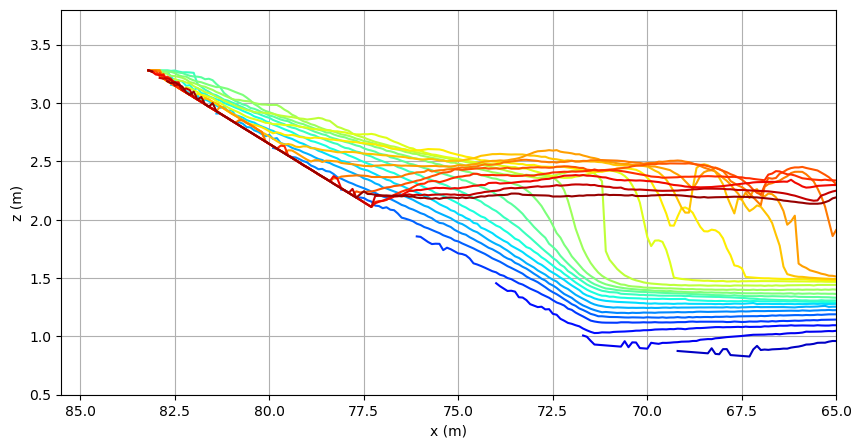

In [18]:
it0 = 1
# it1 = 120
it1 = 80
dt0 = 1
figure,ax=plt.subplots(figsize=(10, 5))
# for idx in range(0,zelevation_all[it0:it1:dt0,:,4].shape[0],2):
for idx in range(3,eta_all[it0:it1:dt0,:,0].shape[0],2):
    # arr = zelevation_all[it0:it1:dt0,:,4][idx]
    arr = eta_all[it0:it1:dt0,:,0][idx]
    arr[arr==0] = np.nan
    # plt.plot(x_grid,arr, label=f'Line {idx}', color=plt.cm.jet(idx / zelevation_all[it0:it1:dt0,:,4].shape[0]))
    plt.plot(x_grid,arr, label=f'Line {idx}', color=plt.cm.jet(idx / eta_all[it0:it1:dt0,:,0].shape[0]))
ax.set_xlim(65, 85.5)
# ax.set_ylim(0.0, 2.4)
ax.set_ylim(0.5, 3.8)
plt.grid()
ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
ax.invert_xaxis()

In [118]:
t.shape

(51,)

In [125]:
y = np.arange(0,1)
t = np.arange(7.5,20+0.25, 0.25)

ds_elevation = xr.Dataset(
    {
        "elevation": (("t", "x_grid", "y"), eta_all)
    },
    coords={
        "t": t,
        "x_grid": x_grid[0:-1],
        "y_grid": y_grid[0:-1]
    }
)
ds_elevation.to_netcdf(f'{fig_folder}/elev_Euler_all_output.nc')
print(f'Saved to folder:  {fig_folder}')

Saved to folder:  figures_MyBreakRoughTank_v3_8a-ii/


## elevation at single time

In [126]:
it0 = 10

ncase=11

r_max = np.zeros((ncase,51))
x_max = np.zeros((ncase,51))

for icase in range(0,ncase):
    Case_folder = Case_folder_a[icase]
    fig_folder = fig_folder_a[icase]
    print(Case_folder,fig_folder)

    # print(fig_folder)
    ds_euler = xr.open_dataset(f'{fig_folder}/elev_Euler_all_output.nc')
    ds_euler
    x_grid = ds_euler.x_grid.values
    eta_all = ds_euler.elevation.values
    # if icase==6:
    #     eta_all = eta_all[30:,:]
    t = ds_euler.t.values
    for it0 in range(51):
        arr = eta_all[it0,:,0]
        # print(eta_all.shape)
        arr[arr==0] = np.nan
        # figure,ax=plt.subplots(figsize=(12, 4))
        # plt.plot(x_grid,arr, label=f'Line {idx}', color=plt.cm.jet(idx / eta_all[it0:it1:dt0,:,0].shape[0]))
        # plt.xlim(70,83)
        # print(arr)

        # find the index of the last not-a-nan element
        last_non_nan_idx = np.where(~np.isnan(arr))[0][-1] if np.any(~np.isnan(arr)) else None
        # print(f"Index of last non-NaN element: {last_non_nan_idx}")
        r_max[icase, it0] = arr[last_non_nan_idx]
        x_max[icase, it0] = x_grid[last_non_nan_idx]



~/work/gpusph/gpusph/tests/MYBreakRoughTank_v3a_2025-12-10T23h09/data/ figures_MyBreakRoughTank_v3_8e_vi_00/
~/work/gpusph/gpusph/tests/MYBreakRoughTank_v3a_2025-12-11T15h10/data/ figures_MyBreakRoughTank_v3_8e_viii_01/
~/work/gpusph/gpusph/tests/MYBreakRoughTank_v3a_2025-12-05T08h58/data/ figures_MyBreakRoughTank_v3_8e_ii_02/
~/work/gpusph/gpusph/tests/MYBreakRoughTank_v3a_2025-12-01T22h58/data/ figures_MyBreakRoughTank_v3_8d/
~/work/gpusph/gpusph/tests/MYBreakRoughTank_v3a_2025-12-05T10h44/data/ figures_MyBreakRoughTank_v3_8e_iii_04/
~/work/gpusph/gpusph/tests/MYBreakRoughTank_v3a_2025-12-14T10h40/data/ figures_MyBreakRoughTank_v3_8e_ix_05/
~/work/gpusph/gpusph/tests/MYBreakRoughTank_v3a_2025-12-06T01h09/data/ figures_MyBreakRoughTank_v3_8e_iv_06/
~/work/gpusph/gpusph/tests/MYBreakRoughTank_v3a_2025-12-14T11h40/data/ figures_MyBreakRoughTank_v3_8e_x_07/
~/work/gpusph/gpusph/tests/MYBreakRoughTank_v3a_2025-12-06T04h18/data/ figures_MyBreakRoughTank_v3_8e_v_08/
~/work/gpusph/gpusph/tes

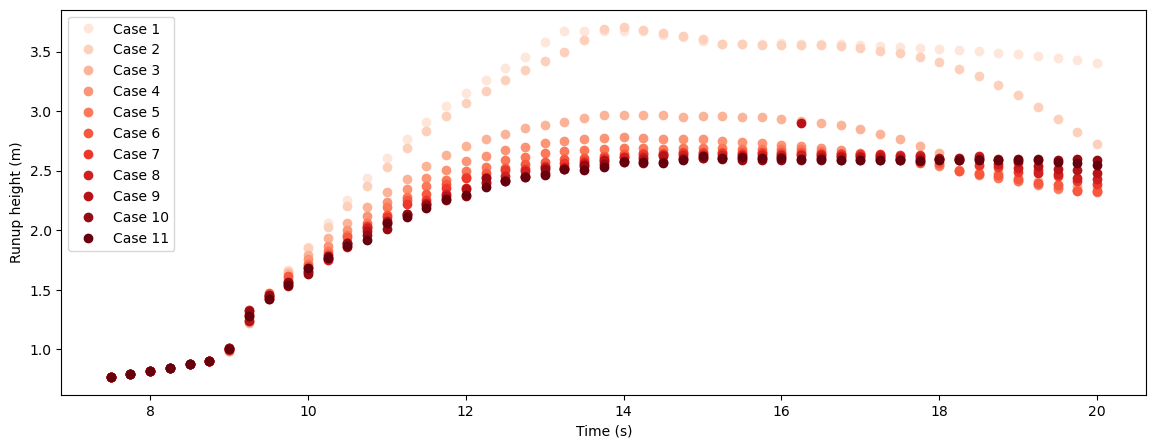

In [215]:
plt.figure(figsize=(14,5))
for i in range(ncase):
    
    plt.plot(np.arange(7.5, 20.25,0.25),r_max[i,:],'o', label=f'Case {i+1}',color=plt.cm.Reds((i+1) / ncase))

plt.xlabel('Time (s)')
plt.ylabel('Runup height (m)')
plt.legend()



In [217]:
np.arange(7.5, 20.25,0.25)[25]

13.75

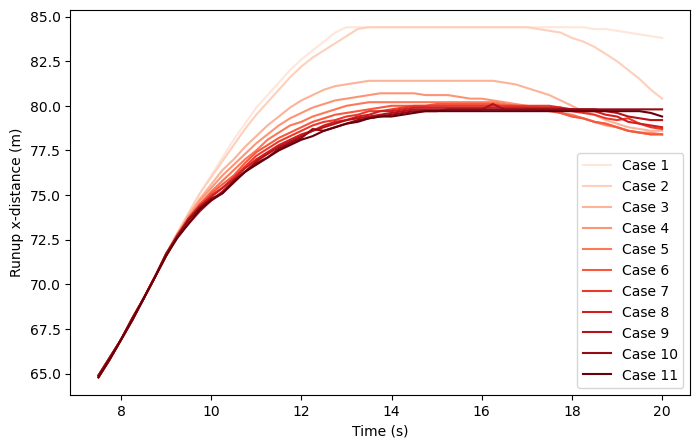

In [128]:
plt.figure(figsize=(8,5))
for i in range(ncase):
    
    plt.plot(np.arange(7.5, 20.25,0.25),x_max[i,:], label=f'Case {i+1}',color=plt.cm.Reds((i+1) / ncase))

plt.xlabel('Time (s)')
plt.ylabel('Runup x-distance (m)')
plt.legend()


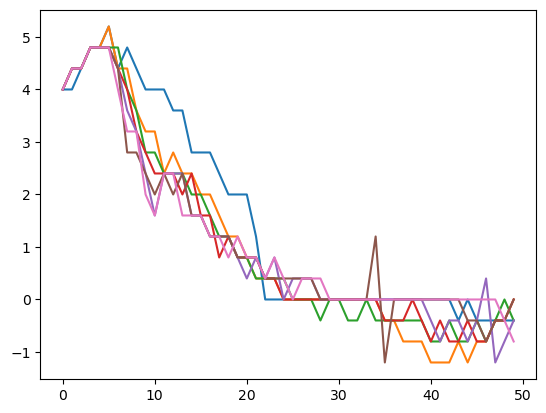

In [93]:
v_front = (x_max[:,1:]-x_max[:,0:-1])/0.25

plt.plot(v_front.T)

Text(0, 0.5, 'Max Runup R (m)')

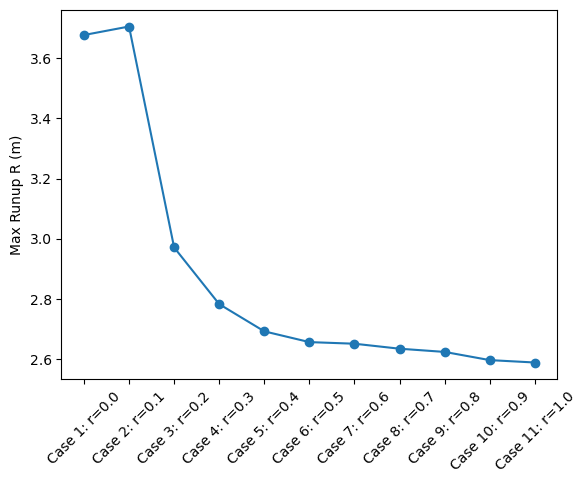

In [132]:
r_max_max = np.max(r_max[:,0:30],axis=1)
figure, ax = plt.subplots()
ax.plot(np.arange(0,1.1,0.1),r_max_max,'-o')
# ax.set_xticks(np.arange(ncase))
ax.set_xticks(np.arange(0,1.1,0.1))
ax.set_xticklabels(['Case 1: r=0.0', 
                    'Case 2: r=0.1', 
                    'Case 3: r=0.2', 
                    'Case 4: r=0.3', 
                    'Case 5: r=0.4', 
                    'Case 6: r=0.5', 
                    'Case 7: r=0.6', 
                    'Case 8: r=0.7', 
                    'Case 9: r=0.8', 
                    'Case 10: r=0.9', 
                    'Case 11: r=1.0'], rotation=45)
plt.ylabel('Max Runup R (m)')


# speed at the toe

In [133]:
# Case_folder = Case_folder_a[5]
# fig_folder = fig_folder_a[5]
# print(Case_folder)
# print(fig_folder)

itmin = 30
itmax = 80
idt = 1
# x_grid = np.arange(0, lx + dx, dx)
x_sec1 = np.arange(70.5, 71.5, 0.5)
y_sec1 = np.arange(0.1, 0.6, 0.4)
x_sec2 = np.arange(73.5, 74.5, 0.5)
y_sec2 = np.arange(0.1, 0.6, 0.4)
# y_grid = np.arange(0, ly + dy, dy)
# y_grid = np.arange(ly/2, ly/2+dy, dy)


for icase in range(11):
    print(icase)
    Case_folder = Case_folder_a[icase]
    fig_folder = fig_folder_a[icase]
    print(Case_folder)
    print(fig_folder)
    eta_sec1 = []
    eta_sec2 = []
    zbottom_sec1 = []
    zbottom_sec2 = []
    vel_sec1 = []
    vel_sec2 = []
    for i in range(itmin,itmax+idt,idt):
        # print(i)
        data = pv.read(f'{Case_folder}PART_{i:05d}.vtp')
        part_water = data.points[np.where(data['Part type']==0)]
        velo_water = data['Velocity'][np.where(data['Part type']==0)]
        x, y, z = part_water[:, 0], part_water[:, 1], part_water[:, 2]
        mask1 = (x >= x_sec1[0]) & (x <= x_sec1[1]) & (y >= y_sec1[0]) & (y <= y_sec1[1])
        mask2 = (x >= x_sec2[0]) & (x <= x_sec2[1]) & (y >= y_sec2[0]) & (y <= y_sec2[1])
        velo_sec1 = velo_water[mask1]
        part_sec1 = part_water[mask1]
        velo_sec2 = velo_water[mask2]
        part_sec2 = part_water[mask2]
    
        # eta, _, _, _ = binned_statistic_2d(
        #     x, y, z, statistic='max', bins=[x_sec, y_sec]
        # )
        # print(part_sec.shape[0])
        if part_sec1.shape[0]>0:
            eta1 = np.max(part_sec1[:,2])
            zbot1 = np.min(part_sec1[:,2])
            vel1 = np.mean(velo_sec1[:,0])
        else:
            eta1 = 0.
            zbot1 = 0.
            vel1 = 0.
        if part_sec2.shape[0]>0:
            eta2 = np.max(part_sec2[:,2])
            zbot2 = np.min(part_sec2[:,2])
            vel2 = np.mean(velo_sec2[:,0])
        else:
            eta2 = 0.
            zbot2 = 0.
            vel2 = 0.
            
        # zbot, _, _, _ = binned_statistic_2d(
        #     x, y, z, statistic='min', bins=[x_sec, y_sec]
        # )
    
        # eta_sec.append(eta)
        eta_sec1.append(eta1)
        vel_sec1.append(vel1)
        eta_sec2.append(eta2)
        vel_sec2.append(vel2)
        zbottom_sec1.append(zbot1)
        zbottom_sec2.append(zbot2)
    # eta_sec = np.array(eta_sec)
    if icase==0:
        eta_sec1_all = np.expand_dims(np.array(eta_sec1),axis=1)
        vel_sec1_all = np.expand_dims(np.array(vel_sec1),axis=1)
        eta_sec2_all = np.expand_dims(np.array(eta_sec2),axis=1)
        vel_sec2_all = np.expand_dims(np.array(vel_sec2),axis=1)
        zbottom_sec1_all = np.expand_dims(np.array(zbottom_sec1),axis=1)
        zbottom_sec2_all = np.expand_dims(np.array(zbottom_sec2),axis=1)
    else:
        eta_sec1_all = np.append(eta_sec1_all, np.expand_dims(np.array(eta_sec1),axis=1), axis=1)
        vel_sec1_all = np.append(vel_sec1_all, np.expand_dims(np.array(vel_sec1),axis=1), axis=1)
        eta_sec2_all = np.append(eta_sec2_all, np.expand_dims(np.array(eta_sec2),axis=1), axis=1)
        vel_sec2_all = np.append(vel_sec2_all, np.expand_dims(np.array(vel_sec2),axis=1), axis=1)
        zbottom_sec1_all = np.append(zbottom_sec1_all, np.expand_dims(np.array(zbottom_sec1),axis=1), axis=1)
        zbottom_sec2_all = np.append(zbottom_sec2_all, np.expand_dims(np.array(zbottom_sec2),axis=1), axis=1)
    print(x_sec, y_sec)

~/work/gpusph/gpusph/tests/MYBreakRoughTank_v3a_2025-12-10T23h09/data/
figures_MyBreakRoughTank_v3_8e_vi_00/
[71.5 72. ] [0.1 0.5]
~/work/gpusph/gpusph/tests/MYBreakRoughTank_v3a_2025-12-11T15h10/data/
figures_MyBreakRoughTank_v3_8e_viii_01/
[71.5 72. ] [0.1 0.5]
~/work/gpusph/gpusph/tests/MYBreakRoughTank_v3a_2025-12-05T08h58/data/
figures_MyBreakRoughTank_v3_8e_ii_02/
[71.5 72. ] [0.1 0.5]
~/work/gpusph/gpusph/tests/MYBreakRoughTank_v3a_2025-12-01T22h58/data/
figures_MyBreakRoughTank_v3_8d/
[71.5 72. ] [0.1 0.5]
~/work/gpusph/gpusph/tests/MYBreakRoughTank_v3a_2025-12-05T10h44/data/
figures_MyBreakRoughTank_v3_8e_iii_04/
[71.5 72. ] [0.1 0.5]
~/work/gpusph/gpusph/tests/MYBreakRoughTank_v3a_2025-12-14T10h40/data/
figures_MyBreakRoughTank_v3_8e_ix_05/
[71.5 72. ] [0.1 0.5]
~/work/gpusph/gpusph/tests/MYBreakRoughTank_v3a_2025-12-06T01h09/data/
figures_MyBreakRoughTank_v3_8e_iv_06/
[71.5 72. ] [0.1 0.5]
~/work/gpusph/gpusph/tests/MYBreakRoughTank_v3a_2025-12-14T11h40/data/
figures_MyBreak

In [134]:
d1 = eta_sec1_all-zbottom_sec1_all
d2 = eta_sec2_all-zbottom_sec2_all

fr1 = vel_sec1_all/np.sqrt(9.81*d1)
fr2 = vel_sec2_all/np.sqrt(9.81*d2)

/tmp/ipykernel_2242460/3826216563.py:4: RuntimeWarning: invalid value encountered in divide
  fr1 = vel_sec1_all/np.sqrt(9.81*d1)
/tmp/ipykernel_2242460/3826216563.py:5: RuntimeWarning: invalid value encountered in divide
  fr2 = vel_sec2_all/np.sqrt(9.81*d2)


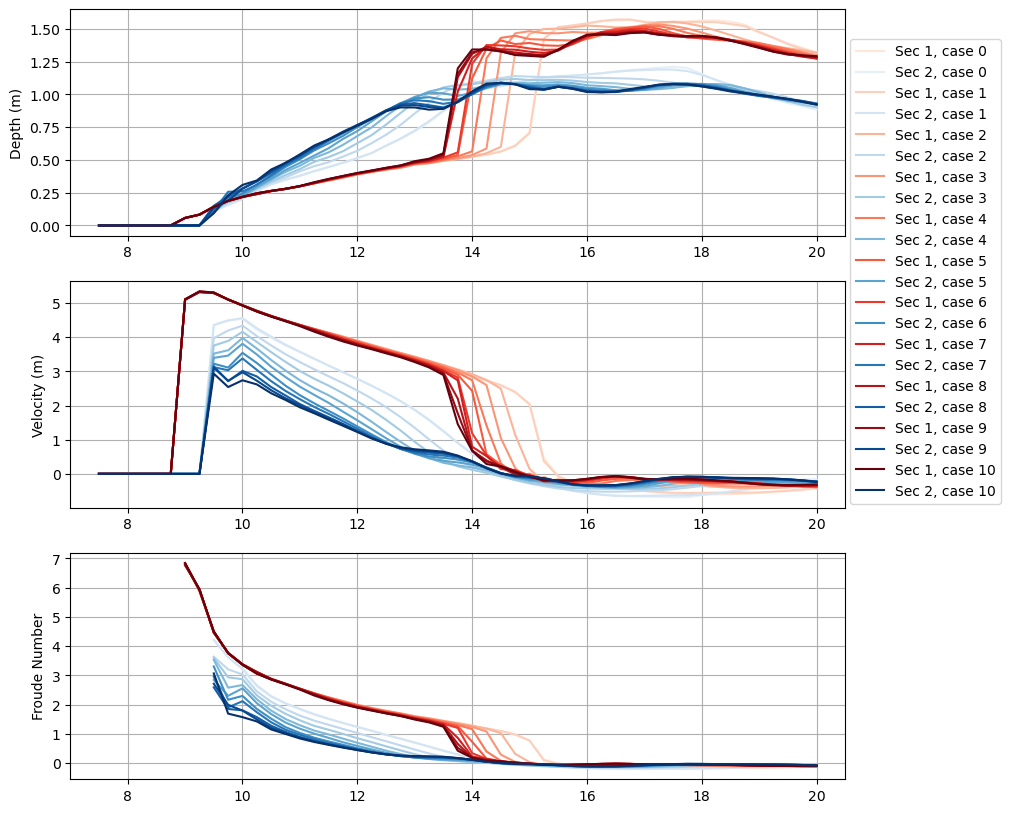

In [162]:
# plt.plot(eta_sec1)
# plt.plot(eta_sec2)
# plt.plot(zbottom_sec1)
# plt.plot(zbottom_sec2)
# icase=0
fig,ax = plt.subplots(3,1,figsize=(10,10))

for icase in range(11):
    ax[0].plot(np.arange(7.5,20.25,0.25),eta_sec1_all[:,icase]-zbottom_sec1_all[:,icase],color=plt.cm.Reds((icase+1) / ncase), label=f'Sec 1, case {icase}')
    ax[0].plot(np.arange(7.5,20.25,0.25),eta_sec2_all[:,icase]-zbottom_sec2_all[:,icase],color=plt.cm.Blues((icase+1) / ncase), label=f'Sec 2, case {icase}')
    ax[0].grid()
    ax[0].set_xlim(7,20.5)
    ax[0].set_ylabel('Depth (m)')
    ax[1].plot(np.arange(7.5,20.25,0.25),vel_sec1_all[:,icase],color=plt.cm.Reds((icase+1) / ncase))
    ax[1].plot(np.arange(7.5,20.25,0.25),vel_sec2_all[:,icase],color=plt.cm.Blues((icase+1) / ncase))
    ax[1].grid()
    ax[1].set_xlim(7,20.5)
    ax[1].set_ylabel('Velocity (m)')
    ax[2].plot(np.arange(7.5,20.25,0.25),fr1[:,icase],color=plt.cm.Reds((icase+1) / ncase))
    ax[2].plot(np.arange(7.5,20.25,0.25),fr2[:,icase],color=plt.cm.Blues((icase+1) / ncase))
    ax[2].grid()
    ax[2].set_xlim(7,20.5)
    ax[2].set_ylabel('Froude Number')
    ax[0].legend(bbox_to_anchor=(1.21, 0.9))

~/work/gpusph/gpusph/tests/MYBreakRoughTank_v3a_2025-12-10T23h09/data/ figures_MyBreakRoughTank_v3_8e_vi_00/
60


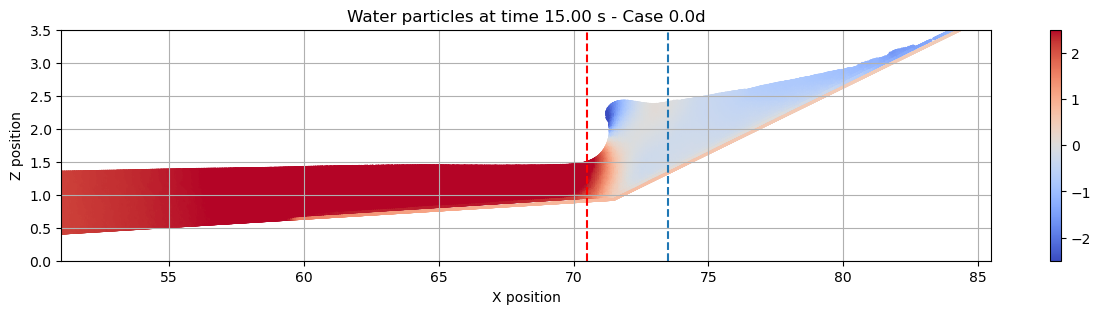

In [177]:
icase=0
Case_folder = Case_folder_a[icase]
fig_folder = fig_folder_a[icase]
print(Case_folder,fig_folder)
# try:
#     os.mkdir(fig_folder)
#     print(f"Folder '{fig_folder}' created.")
# except FileExistsError:
#     print(f"Folder '{fig_folder}' already exists.")

for i in range(60,61):
    print(i)
    data = pv.read(f'{Case_folder}PART_{i:05d}.vtp')
    # data = pv.read(f'WaveTank_2025-08-19T00h39/data/PART_{i:05d}.vtp')
    # data = pv.read(f'HinsdaleFlume_2025-08-22T00h42/data/PART_{i:05d}.vtp')
    part_water = data.points[np.where(data['Part type']==0)]
    # part_water = data.points[np.where((data['Part type']==0)|(data['Part type']==1))]
    velo_water = data['Velocity'][np.where(data['Part type']==0)]
    # velo_water = data['Velocity'][np.where((data['Part type']==0)|(data['Part type']==1))]

    # Find water particles with y-coordinates between 1.45 and 1.55
    # mask = (part_water[:, 1] >= 0.1) & (part_water[:, 1] <= 0.2)
    mask = (part_water[:, 1] >= 0.95) & (part_water[:, 1] <= 1.05)
    filtered_particles = part_water[mask]
    velo_particles = velo_water[mask]
    # speed_particles = np.sqrt(velo_particles[:,0]**2+velo_particles[:,1]**2+velo_particles[:,2]**2)

    plt.figure(figsize=(15, 3))
    plt.scatter(filtered_particles[:, 0], filtered_particles[:, 2], s=1, c=velo_particles[:,0],cmap='coolwarm',vmax=2.5,vmin=-2.5, alpha=1)
    plt.vlines(70.5,0, 3.5,linestyles='dashed', colors='Red')
    plt.vlines(73.5,0, 3.5,linestyles='dashed')

    plt.colorbar()
    plt.xlabel('X position')
    plt.ylabel('Z position')
    # plt.xlim(0,45.5)
    plt.xlim(51,85.5)
    plt.ylim(0.,3.5)
    plt.title(f'Water particles at time {i*0.25:.2f} s - Case {cname[icase]}')
    plt.grid(True)

In [227]:


itmin = 30
itmax = 80
idt = 1
# x_grid = np.arange(0, lx + dx, dx)
x_slope1 = np.arange(71.5, 85.6, 14)

y_slope1 = np.arange(0.3, 0.46, 0.1)
print(x_slope1,y_slope1)
# x_sec2 = np.arange(73.5, 74.5, 0.5)
# y_sec2 = np.arange(0.1, 0.6, 0.4)
# y_grid = np.arange(0, ly + dy, dy)
# y_grid = np.arange(ly/2, ly/2+dy, dy)

icase = 0
print(icase)
Case_folder = Case_folder_a[icase]
fig_folder = fig_folder_a[icase]
print(Case_folder)
print(fig_folder)
# eta_sec1 = []
# eta_sec2 = []
# zbottom_sec1 = []
# zbottom_sec2 = []
# vel_sec1 = []
# vel_sec2 = []
i=55 
# for i in range(itmin,itmax+idt,idt):
    # print(i)
data = pv.read(f'{Case_folder}PART_{i:05d}.vtp')
part_water = data.points[np.where(data['Part type']==0)]
velo_water = data['Velocity'][np.where(data['Part type']==0)]
x, y, z = part_water[:, 0], part_water[:, 1], part_water[:, 2]
# mask1 =  (y >= y_slope1[0]) & (y <= y_slope1[1])
mask1 = (x >= x_slope1[0]) & (x <= x_slope1[1]) & (y >= y_slope1[0]) & (y <= y_slope1[1])
# mask2 = (x >= x_sec2[0]) & (x <= x_sec2[1]) & (y >= y_sec2[0]) & (y <= y_sec2[1])
velo_slope1 = velo_water[mask1]
part_slope1 = part_water[mask1]
# velo_sec2 = velo_water[mask2]
# part_sec2 = part_water[mask2]


[71.5 85.5] [0.3 0.4]
0
~/work/gpusph/gpusph/tests/MYBreakRoughTank_v3a_2025-12-10T23h09/data/
figures_MyBreakRoughTank_v3_8e_vi_00/


(0.0, 3.8)

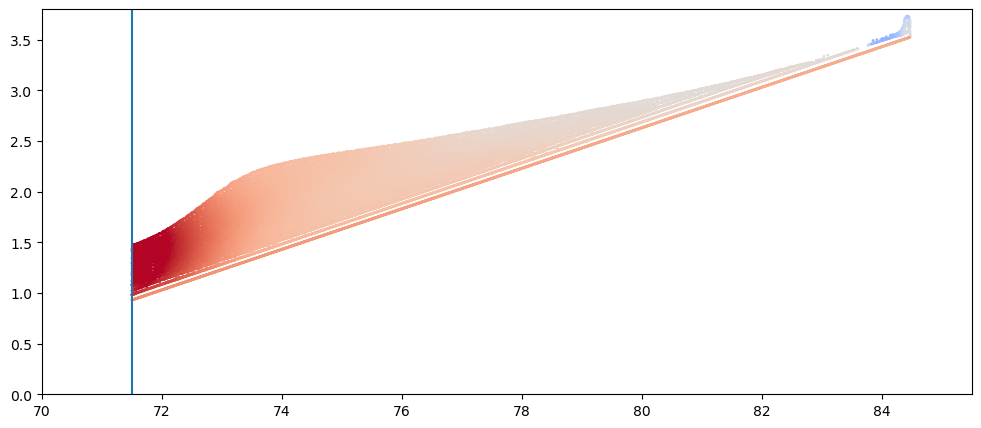

In [229]:
plt.figure(figsize=(12,5))
plt.scatter(part_slope1[:, 0], part_slope1[:, 2], s=1, c=velo_slope1[:,0],cmap='coolwarm',vmax=2.5,vmin=-2.5, alpha=1)
plt.vlines(71.5,0,3.8)

plt.xlim(70,85.5)
plt.ylim(0.,3.8)

In [ ]:
vel_slope = []
pos_slope = []
for i in range(35,80):
    print(i)
    data = pv.read(f'{Case_folder}PART_{i:05d}.vtp')
    part_water = data.points[np.where(data['Part type']==0)]
    velo_water = data['Velocity'][np.where(data['Part type']==0)]
    # x, y, z = part_water[:, 0], part_water[:, 1], part_water[:, 2]
    
    velo_slope_t = velo_water[mask1]
    part_slope_t = part_water[mask1]

    
    pos_slope.append(part_slope_t)
    vel_slope.append(velo_slope_t)

In [ ]:
###### vel_slope = np.array(vel_slope)
pos_slope = np.array(pos_slope)


In [206]:
KE = 0.5*(vel_slope[:,:,0]**2+vel_slope[:,:,2]**2)

PE = 9.81*pos_slope[:,:,2]

In [208]:
KE_sum_1 = np.sum(KE,axis=1)
PE_sum_1 = np.sum(PE,axis=1)

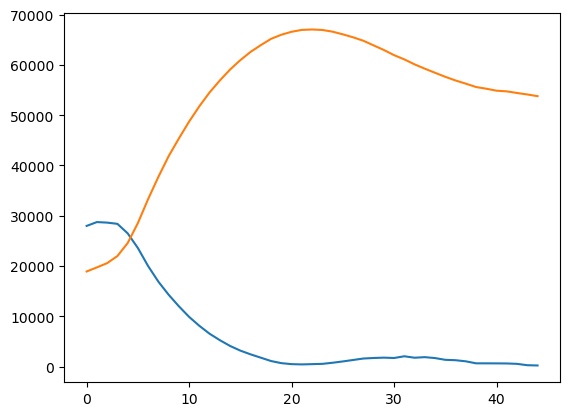

In [210]:
plt.plot(KE_sum)
plt.plot(PE_sum)


(1.0, 3.5)

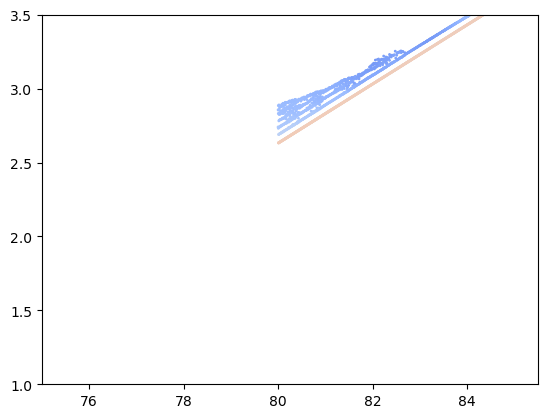

In [213]:
plt.scatter(part_slope1[:, 0], part_slope1[:, 2], s=1, c=velo_slope1[:,0],cmap='coolwarm',vmax=2.5,vmin=-2.5, alpha=1)

plt.xlim(75,85.5)
plt.ylim(1.,3.5)

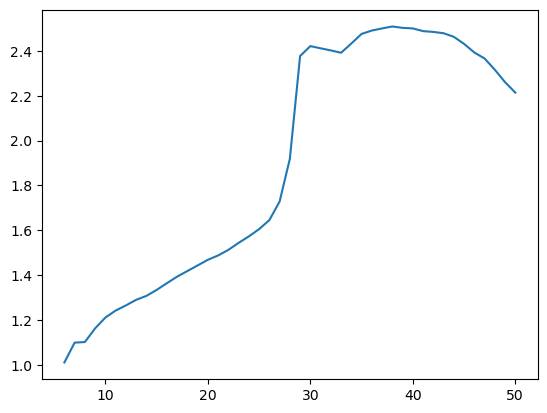

In [7]:
eta_sec.shape
plt.plot(eta_sec[:,0,0])

In [ ]:
it0 = 0
# it1 = 120
it1 = 30
dt0 = 1
figure,ax=plt.subplots(figsize=(10, 5))
# for idx in range(0,zelevation_all[it0:it1:dt0,:,4].shape[0],2):
for idx in range(0,eta_all[it0:it1:dt0,:,0].shape[0],2):
    # arr = zelevation_all[it0:it1:dt0,:,4][idx]
    arr = eta_all[it0:it1:dt0,:,0][idx]
    arr[arr==0] = np.nan
    # plt.plot(x_grid,arr, label=f'Line {idx}', color=plt.cm.jet(idx / zelevation_all[it0:it1:dt0,:,4].shape[0]))
    plt.plot(x_grid[0:-1],arr, label=f'Line {idx}', color=plt.cm.jet(idx / eta_all[it0:it1:dt0,:,0].shape[0]))
ax.set_xlim(20, 50)
ax.set_ylim(0.3, 1.5)
plt.grid()
# ax.invert_xaxis()

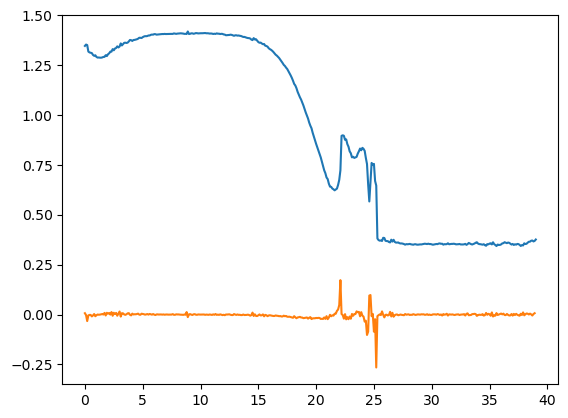

In [20]:
it0=6
eta_0 = eta_all[it0,:,0]

grad_eta_0 = np.diff(eta_0)


plt.plot(x_grid[0:-1],eta_0)

plt.plot(x_grid[0:-2],grad_eta_0)